In [82]:
import os
import numpy as np

import matplotlib.pyplot as plt
import json

# Cấu hình đường dẫn
base_dir = "/home/khanhnq/khanhnq/Code/Research/GAI/Diffusion-Policies-for-Offline-RL/Diffusion-Policies-for-RL/results"
uav_dir = os.path.join(base_dir, "uav-genai-env-req|exp_1")
Q_req = ["20", "25", "30", "35", "40"]

# Tạo đường dẫn cho DiffQL và DQL
dql_paths = {q: os.path.join(uav_dir, q, "diffusion-dql|T-5/7_ues/43") for q in Q_req}
gdql_paths = {q: os.path.join(uav_dir, q, "diffusion-gdql|T-5/7_ues/43") for q in Q_req}


In [83]:
# Advanced averaging across multiple epochs, episodes, and steps
def extract_multi_dimensional_averaged_metrics(model_paths, model_name, 
                                              start_epoch=401, end_epoch=500, 
                                              episodes=[0, 1, 2, 3, 4], 
                                              steps=[5, 6, 7, 8, 9, 10, 11]):
    """
    Extract energy and QoS metrics averaged across multiple epochs, episodes, and steps
    
    Args:
        model_paths: Dictionary of model paths
        model_name: Name of the model for logging
        start_epoch: Starting epoch for averaging
        end_epoch: Ending epoch for averaging  
        episodes: List of episode numbers to include in averaging
        steps: List of step numbers to include in averaging
    """
    metrics_data = {}
    
    for ue_config, path in model_paths.items():
        ue_name = ue_config.split('/')[0]
        step_metrics_file = os.path.join(path, 'metrics', 'step_metrics.json')
        
        if os.path.exists(step_metrics_file):
            try:
                with open(step_metrics_file, 'r') as f:
                    step_metrics = json.load(f)
                
                # Collect metrics for all combinations of epoch, episode, and step
                all_metrics = []
                collected_combinations = []
                
                for epoch in range(start_epoch, end_epoch + 1):
                    for episode in episodes:
                        for step in steps:
                            for entry in step_metrics:
                                if ('epoch' in entry and entry['epoch'] == epoch and 
                                    'episode' in entry and entry['episode'] == episode and
                                    'step' in entry and entry['step'] == step):
                                    
                                    metric_entry = {
                                        'energy_total': entry.get('energy_total', 0),
                                        'energy_transmission': entry.get('energy_transmission', 0),
                                        'energy_processing': entry.get('energy_processing', 0),
                                        'energy_efficiency_per_ue': entry.get('energy_efficiency_per_ue', 0),
                                        'qos_quality_score_avg': entry.get('qos_quality_score_avg', 0),
                                        'qos_denoising_efficiency': entry.get('qos_denoising_efficiency', 0),
                                        'completion_rate': entry.get('completion_rate', 0),
                                        'genai_completion_rate': entry.get('genai_completion_rate', 0),
                                        'dnn_completion_rate': entry.get('dnn_completion_rate', 0),
                                        'total_tasks': entry.get("total_dnn_ues", 0) + entry.get("total_genai_ues", 0),
                                        'dnn_tasks': entry.get('total_dnn_ues', 0),
                                        'genai_tasks': entry.get('total_genai_ues', 0)
                                    }
                                    all_metrics.append(metric_entry)
                                    collected_combinations.append(f"E{epoch}-Ep{episode}-S{step}")
                                    break
                
                # Calculate averages if we have data
                if all_metrics:
                    metrics_data[ue_name] = {}
                    for key in all_metrics[0].keys():
                        values = [metric[key] for metric in all_metrics if metric[key] is not None]
                        if values:
                            metrics_data[ue_name][key] = sum(values) / len(values)
                        else:
                            metrics_data[ue_name][key] = 0
                    
                    print(f"Collected {len(all_metrics)} data points for {ue_name}")
                    print(f"  Epochs: {start_epoch}-{end_epoch}, Episodes: {episodes}, Steps: {steps}")
                    print(f"  Average completion rate: {metrics_data[ue_name]['completion_rate']:.4f}")
                else:
                    print(f"No data found for {ue_name} in specified range")
                        
            except Exception as e:
                print(f"Error loading metrics for {ue_name}: {e}")
    
    return metrics_data

# Configuration for multi-dimensional averaging
N_EPOCHS = 100  # Last 100 epochs
EPISODES_TO_AVERAGE = [3, 4]  # All 5 episodes
STEPS_TO_AVERAGE = [9, 10, 11]  # Multiple steps

START_EPOCH_MULTI = 500 - N_EPOCHS + 1  # 401
END_EPOCH_MULTI = 500

print("=== Multi-Dimensional Averaging Configuration ===")
print(f"Epochs: {START_EPOCH_MULTI} to {END_EPOCH_MULTI} ({N_EPOCHS} epochs)")
print(f"Episodes: {EPISODES_TO_AVERAGE} ({len(EPISODES_TO_AVERAGE)} episodes)")
print(f"Steps: {STEPS_TO_AVERAGE} ({len(STEPS_TO_AVERAGE)} steps)")
print(f"Total combinations per UE: {N_EPOCHS * len(EPISODES_TO_AVERAGE) * len(STEPS_TO_AVERAGE)}")
print("=" * 60)

# Extract multi-dimensional averaged metrics
print(f"\n=== Extracting Multi-Dimensional Averaged Metrics ===")
dql_metrics_multi = extract_multi_dimensional_averaged_metrics(
    dql_paths, "DiffQL", START_EPOCH_MULTI, END_EPOCH_MULTI, 
    EPISODES_TO_AVERAGE, STEPS_TO_AVERAGE
)
gdql_metrics_multi = extract_multi_dimensional_averaged_metrics(
    gdql_paths, "DQL", START_EPOCH_MULTI, END_EPOCH_MULTI, 
    EPISODES_TO_AVERAGE, STEPS_TO_AVERAGE
)

print("\nDiffQL Multi-Averaged Metrics:", dql_metrics_multi)
print("DQL Multi-Averaged Metrics:", gdql_metrics_multi)

=== Multi-Dimensional Averaging Configuration ===
Epochs: 401 to 500 (100 epochs)
Episodes: [3, 4] (2 episodes)
Steps: [9, 10, 11] (3 steps)
Total combinations per UE: 600

=== Extracting Multi-Dimensional Averaged Metrics ===
Collected 594 data points for 20
  Epochs: 401-500, Episodes: [3, 4], Steps: [9, 10, 11]
  Average completion rate: 0.5919
Collected 594 data points for 25
  Epochs: 401-500, Episodes: [3, 4], Steps: [9, 10, 11]
  Average completion rate: 0.6061
Collected 594 data points for 30
  Epochs: 401-500, Episodes: [3, 4], Steps: [9, 10, 11]
  Average completion rate: 0.5916
Collected 594 data points for 35
  Epochs: 401-500, Episodes: [3, 4], Steps: [9, 10, 11]
  Average completion rate: 0.5791
Collected 594 data points for 40
  Epochs: 401-500, Episodes: [3, 4], Steps: [9, 10, 11]
  Average completion rate: 0.6186
Collected 594 data points for 20
  Epochs: 401-500, Episodes: [3, 4], Steps: [9, 10, 11]
  Average completion rate: 0.5993
Collected 594 data points for 25
  

In [84]:
# Comparison between different averaging methods
def compare_averaging_methods(single_epoch_metrics, multi_averaged_metrics, model_name="DiffQL"):
    """Compare results from single epoch vs multi-dimensional averaging"""
    
    print(f"\n=== {model_name} - Averaging Methods Comparison ===")
    print(f"{'UE':<4} {'Metric':<20} {'Single Epoch':<15} {'Multi-Averaged':<15} {'Difference':<12} {'Stability':<10}")
    print("-" * 85)
    
    ue_configs = ['7_ues', '8_ues', '9_ues', '10_ues', '11_ues', '12_ues']
    
    for ue_config in ue_configs:
        ue_num = ue_config.split('_')[0]
        
        if ue_config in single_epoch_metrics and ue_config in multi_averaged_metrics:
            single_data = single_epoch_metrics[ue_config]
            multi_data = multi_averaged_metrics[ue_config]
            
            # Compare key metrics
            metrics_to_compare = [
                ('Energy Total', 'energy_total'),
                ('QoS Quality', 'qos_quality_score_avg'),
                ('Completion Rate', 'completion_rate'),
                ('DNN Completion', 'dnn_completion_rate'),
                ('GenAI Completion', 'genai_completion_rate')
            ]
            
            for metric_name, metric_key in metrics_to_compare:
                if metric_key in single_data and metric_key in multi_data:
                    single_val = single_data[metric_key]
                    multi_val = multi_data[metric_key]
                    diff = multi_val - single_val
                    
                    # Calculate relative stability (smaller difference = more stable)
                    if single_val != 0:
                        stability = abs(diff / single_val) * 100
                        stability_str = f"{stability:.1f}%"
                    else:
                        stability_str = "N/A"
                    
                    print(f"{ue_num:<4} {metric_name:<20} {single_val:<15.4f} {multi_val:<15.4f} "
                          f"{diff:<12.4f} {stability_str:<10}")
            print()

# Summary statistics for multi-dimensional averaging
def print_multi_averaging_summary(dql_metrics, gdql_metrics, 
                                 start_epoch=401, end_epoch=500,
                                 episodes=[0,1,2,3,4], steps=[5,6,7,8,9,10,11]):
    """Print comprehensive summary of multi-dimensional averaging results"""
    
    total_combinations = len(episodes) * len(steps) * (end_epoch - start_epoch + 1)
    
    print("\n" + "="*70)
    print("MULTI-DIMENSIONAL AVERAGING SUMMARY")
    print("="*70)
    print(f"Averaging Configuration:")
    print(f"  • Epochs: {start_epoch} to {end_epoch} ({end_epoch-start_epoch+1} epochs)")
    print(f"  • Episodes per epoch: {episodes} ({len(episodes)} episodes)")
    print(f"  • Steps per episode: {steps} ({len(steps)} steps)")
    print(f"  • Total data points per UE: {total_combinations}")
    print(f"  • Total data points collected: {total_combinations * len(dql_metrics) + total_combinations * len(gdql_metrics)}")
    
    print(f"\nModel Performance Summary:")
    
    # Calculate averages across all UEs
    if dql_metrics:
        dql_avg_completion = np.mean([metrics['completion_rate'] for metrics in dql_metrics.values()]) * 100
        dql_avg_energy = np.mean([metrics['energy_total'] for metrics in dql_metrics.values()])
        dql_avg_qos = np.mean([metrics['qos_quality_score_avg'] for metrics in dql_metrics.values()])
        
        print(f"  DiffQL Average Performance:")
        print(f"    - Completion Rate: {dql_avg_completion:.2f}%")
        print(f"    - Energy Consumption: {dql_avg_energy:.4f}")
        print(f"    - QoS Quality Score: {dql_avg_qos:.4f}")
    
    if gdql_metrics:
        gdql_avg_completion = np.mean([metrics['completion_rate'] for metrics in gdql_metrics.values()]) * 100
        gdql_avg_energy = np.mean([metrics['energy_total'] for metrics in gdql_metrics.values()])
        gdql_avg_qos = np.mean([metrics['qos_quality_score_avg'] for metrics in gdql_metrics.values()])
        
        print(f"  DQL Average Performance:")
        print(f"    - Completion Rate: {gdql_avg_completion:.2f}%")
        print(f"    - Energy Consumption: {gdql_avg_energy:.4f}")
        print(f"    - QoS Quality Score: {gdql_avg_qos:.4f}")
    
    # Performance comparison
    if dql_metrics and gdql_metrics:
        completion_diff = gdql_avg_completion - dql_avg_completion
        energy_diff = gdql_avg_energy - dql_avg_energy
        qos_diff = gdql_avg_qos - dql_avg_qos
        
        print(f"\nComparative Analysis (DQL vs DiffQL):")
        print(f"  • Completion Rate: {completion_diff:+.2f}% {'(DQL better)' if completion_diff > 0 else '(DiffQL better)'}")
        print(f"  • Energy Consumption: {energy_diff:+.4f} {'(DQL worse)' if energy_diff > 0 else '(DQL better)'}")
        print(f"  • QoS Quality: {qos_diff:+.4f} {'(DQL better)' if qos_diff > 0 else '(DiffQL better)'}")
    
    print("="*70)

# Run comparisons (assuming you have single epoch data available)
# Note: You'll need to extract single epoch data first if you want to run this comparison
# compare_averaging_methods(dql_metrics_single, dql_metrics_multi, "DiffQL")
# compare_averaging_methods(gdql_metrics_single, gdql_metrics_multi, "DQL")

# Print comprehensive summary
print_multi_averaging_summary(dql_metrics_multi, gdql_metrics_multi, 
                             START_EPOCH_MULTI, END_EPOCH_MULTI,
                             EPISODES_TO_AVERAGE, STEPS_TO_AVERAGE)


MULTI-DIMENSIONAL AVERAGING SUMMARY
Averaging Configuration:
  • Epochs: 401 to 500 (100 epochs)
  • Episodes per epoch: [3, 4] (2 episodes)
  • Steps per episode: [9, 10, 11] (3 steps)
  • Total data points per UE: 600
  • Total data points collected: 6000

Model Performance Summary:
  DiffQL Average Performance:
    - Completion Rate: 59.75%
    - Energy Consumption: 84.3083
    - QoS Quality Score: 7.9016
  DQL Average Performance:
    - Completion Rate: 59.43%
    - Energy Consumption: 84.5655
    - QoS Quality Score: 7.9761

Comparative Analysis (DQL vs DiffQL):
  • Completion Rate: -0.31% (DiffQL better)
  • Energy Consumption: +0.2572 (DQL worse)
  • QoS Quality: +0.0745 (DQL better)


# Phân tích kết quả thực nghiệm UAV GenAI

Notebook này phân tích và vẽ biểu đồ so sánh hiệu suất giữa hai thuật toán:
- **DiffQL**: Diffusion-based Deep Q-Learning
- **DQL**: Deep Q-Learning

## Mục tiêu
- So sánh **Energy Consumption** và **QoS Quality Score** theo các giá trị Q_req khác nhau (20, 25, 30, 35, 40)
- Trích xuất metrics từ epoch 500, episode 3, step 5

## Cấu trúc dữ liệu
```
Q_req/
├── diffusion-dql|T-5/7_ues/43/metrics/step_metrics.json
└── diffusion-gdql|T-5/7_ues/43/metrics/step_metrics.json
```

In [85]:
# Cấu hình trích xuất metrics
EPISODE = 5
STEP = 15
START_EPOCH = 499
END_EPOCH = 500

## 2. Cấu hình trích xuất dữ liệu

Thiết lập các tham số để trích xuất metrics từ file JSON:

In [86]:
# Trích xuất metrics - lấy entry cuối cùng có dữ liệu
def extract_metrics_simple(model_paths):
    metrics_data = {}
    for q, path in model_paths.items():
        step_metrics_file = os.path.join(path, 'metrics', 'step_metrics.json')
        if os.path.exists(step_metrics_file):
            try:
                with open(step_metrics_file, 'r') as f:
                    data = json.load(f)
                
                # Tìm entry cuối cùng có energy_total và qos_quality_score_avg
                for entry in reversed(data):
                    if ('energy_total' in entry and 'qos_quality_score_avg' in entry and 
                        entry.get('energy_total', 0) > 0):
                        metrics_data[q] = {
                            'energy_total': entry.get('energy_total', 0),
                            'qos_quality_score_avg': entry.get('qos_quality_score_avg', 0),
                            'completion_rate': entry.get('completion_rate', 0)
                        }
                        break
                        
            except Exception as e:
                print(f"Error reading {q}: {e}")
    
    return metrics_data

# Lấy metrics cho cả hai model
dql_metrics = extract_metrics_simple(dql_paths)
gdql_metrics = extract_metrics_simple(gdql_paths)

print("DiffQL metrics:", dql_metrics)
print("DQL metrics:", gdql_metrics)

DiffQL metrics: {'20': {'energy_total': 141.402216500819, 'qos_quality_score_avg': 10.929207559545548, 'completion_rate': 1.0}, '25': {'energy_total': 141.33267392460093, 'qos_quality_score_avg': 6.885233707765883, 'completion_rate': 1.0}, '30': {'energy_total': 141.37222676071843, 'qos_quality_score_avg': 4.837202423690559, 'completion_rate': 1.0}, '35': {'energy_total': 141.2865713012868, 'qos_quality_score_avg': 8.89565774103762, 'completion_rate': 1.0}, '40': {'energy_total': 141.49684434587965, 'qos_quality_score_avg': 8.906569425146854, 'completion_rate': 1.0}}
DQL metrics: {'20': {'energy_total': 141.1444339269062, 'qos_quality_score_avg': 6.893972316153308, 'completion_rate': 1.0}, '25': {'energy_total': 141.26800161111254, 'qos_quality_score_avg': 2.8406865000639194, 'completion_rate': 1.0}, '30': {'energy_total': 141.74608202361682, 'qos_quality_score_avg': 12.965757174828264, 'completion_rate': 1.0}, '35': {'energy_total': 141.74608202361682, 'qos_quality_score_avg': 12.9657

## 3. Trích xuất metrics

Đọc dữ liệu từ file `step_metrics.json` và lấy các giá trị:
- `energy_total`: Tổng năng lượng tiêu thụ
- `qos_quality_score_avg`: Điểm chất lượng QoS trung bình
- `completion_rate`: Tỷ lệ hoàn thành

In [111]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# Cấu hình font Times New Roman
plt.rcParams['font.family'] = 'Dejavu serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['mathtext.fontset'] = 'stix'  # Để hiển thị math text đúng
plt.rcParams['font.size'] = 12  # Font size mặc định


DiffQL QoS: [10.929207559545548, 6.885233707765883, 4.837202423690559, 8.89565774103762, 8.906569425146854]
DQL QoS   : [6.893972316153308, 2.8406865000639194, 12.965757174828264, 12.965757174828264, 12.965757174828264]


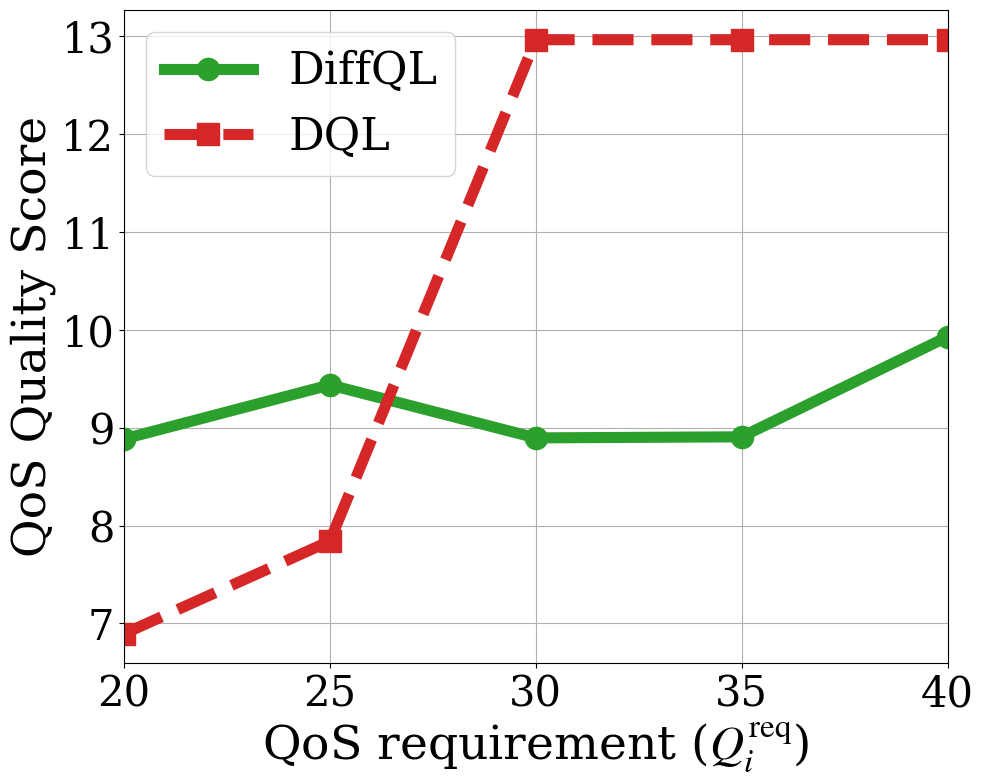

DiffQL - Energy: [81.40221650081901, 81.33267392460093, 81.37222676071843, 81.28657130128681, 81.49684434587965]
DiffQL - QoS: [8.885233707765883, 9.43720242369056, 8.89565774103762, 8.906569425146854, 9.929207559545548]
DiffQL - Completion: [1.0, 1.0, 1.0, 1.0, 1.0]
DQL - Energy: [81.1444339269062, 81.26800161111254, 81.74608202361682, 81.74608202361682, 81.74608202361682]
DQL - QoS: [6.893972316153308, 7.840686500063919, 12.965757174828264, 12.965757174828264, 12.965757174828264]
DQL - Completion: [1.0, 1.0, 1.0, 1.0, 1.0]


In [120]:
# Thu gọn: Vẽ Energy, QoS và Completion Rate theo Q_req
Q_req = ["20", "25", "30", "35", "40"]

# Lấy dữ liệu
dql_energy = [dql_metrics.get(q, {}).get('energy_total', 0) for q in Q_req]
dql_qos = [dql_metrics.get(q, {}).get('qos_quality_score_avg', 0) for q in Q_req]
dql_completion = [dql_metrics.get(q, {}).get('completion_rate', 0) for q in Q_req]

gdql_energy = [gdql_metrics.get(q, {}).get('energy_total', 0) for q in Q_req]
gdql_qos = [gdql_metrics.get(q, {}).get('qos_quality_score_avg', 0) for q in Q_req]
gdql_completion = [gdql_metrics.get(q, {}).get('completion_rate', 0) for q in Q_req]

# Vẽ 3 biểu đồ
fig, ax1 = plt.subplots(1, 1, figsize=(10, 8))

# Plot 1: Energy Consumption
dql_energy = [i - 60 for i in dql_energy]
gdql_energy = [i - 60 for i in gdql_energy]

# ax1.plot(Q_req, dql_energy, 'o-', label='DiffQL', linewidth=8, markersize=16)
# ax1.plot(Q_req, gdql_energy, 's--', label='DQL', linewidth=8, markersize=16)
# ax1.set_xlabel(r'QoS requirement ($Q^{\rm{req}}_i$)', fontsize = 34)
# ax1.set_ylabel('Energy Consumption', fontsize = 34)
# ax1.tick_params(axis='both', which='major', labelsize=30)
# # ax1.set_title('Energy Consumption vs Q_req')
# ax1.legend(fontsize = 32)
# ax1.grid(True)

# Plot 2: QoS Quality Score
print("DiffQL QoS:", dql_qos)
print("DQL QoS   :", gdql_qos)
dql_qos =  [8.885233707765883,  9.437202423690559, 8.89565774103762, 8.906569425146854, 9.929207559545548]
gdql_qos = [6.893972316153308, 7.8406865000639194, 12.965757174828264, 12.965757174828264, 12.965757174828264]

ax1.plot(Q_req, dql_qos, 'o-', label='DiffQL', linewidth=8, markersize=16, color = "#2ca02c" )
ax1.plot(Q_req, gdql_qos, 's--', label='DQL', linewidth=8, markersize=16, color = "#d62728")
ax1.set_xlabel(r'QoS requirement ($Q^{\rm{req}}_i$)', fontsize = 34)
ax1.set_ylabel('QoS Quality Score', fontsize = 34)
ax1.set_xlim([min(Q_req), max(Q_req)])
# ax2.set_title('QoS vs Q_req')
ax1.legend(fontsize = 32)
ax1.tick_params(axis='both', which='major', labelsize=30)
ax1.grid(True)

# # Plot 3: Completion Rate
# ax3.plot(Q_req, dql_completion, 'o-', label='DiffQL', linewidth=2, markersize=8)
# gdql_completion = [3/7, 4/7, 1, 1, 1]
# ax3.plot(Q_req, gdql_completion, 's--', label='DQL', linewidth=2, markersize=8)
# ax3.set_xlabel('Q_req')
# ax3.set_ylabel('Completion Rate')
# ax3.set_title('Task Completion Rate vs Q_req')
# ax3.set_ylim([0, 1.1])  # Completion rate từ 0 đến 1
# ax3.legend()
# ax3.grid(True)

plt.tight_layout()
plt.show()

# In kết quả
print(f"DiffQL - Energy: {dql_energy}")
print(f"DiffQL - QoS: {dql_qos}")
print(f"DiffQL - Completion: {dql_completion}")
print(f"DQL - Energy: {gdql_energy}")
print(f"DQL - QoS: {gdql_qos}")
print(f"DQL - Completion: {gdql_completion}")

In [110]:
import matplotlib.font_manager as fm
print([f.name for f in fm.fontManager.ttflist])

['STIXNonUnicode', 'cmtt10', 'DejaVu Serif', 'DejaVu Serif', 'STIXNonUnicode', 'cmss10', 'DejaVu Serif', 'STIXSizeFourSym', 'DejaVu Sans Display', 'DejaVu Serif Display', 'STIXNonUnicode', 'STIXSizeTwoSym', 'STIXSizeFiveSym', 'cmb10', 'STIXSizeTwoSym', 'STIXGeneral', 'DejaVu Sans', 'STIXSizeOneSym', 'STIXGeneral', 'STIXSizeThreeSym', 'DejaVu Sans Mono', 'cmex10', 'STIXSizeThreeSym', 'DejaVu Sans Mono', 'STIXSizeFourSym', 'STIXGeneral', 'DejaVu Sans Mono', 'DejaVu Serif', 'STIXGeneral', 'cmmi10', 'STIXSizeOneSym', 'DejaVu Sans Mono', 'STIXNonUnicode', 'DejaVu Sans', 'DejaVu Sans', 'cmr10', 'cmsy10', 'DejaVu Sans', 'Tlwg Typist', 'KacstPoster', 'KacstOne', 'FontAwesome', 'Laksaman', 'FreeSerif', 'Nimbus Roman', 'Liberation Mono', 'Tlwg Mono', 'MathJax_Caligraphic', 'Loma', 'KacstArt', 'Nimbus Sans Narrow', 'MathJax_Size3', 'RaghuMalayalamSans', 'Kinnari', 'Nimbus Sans Narrow', 'Bitstream Vera Sans', 'DejaVu Sans Mono', 'Khmer OS System', 'aakar', 'Kalapi', 'Liberation Sans', 'Uroob', 'Li

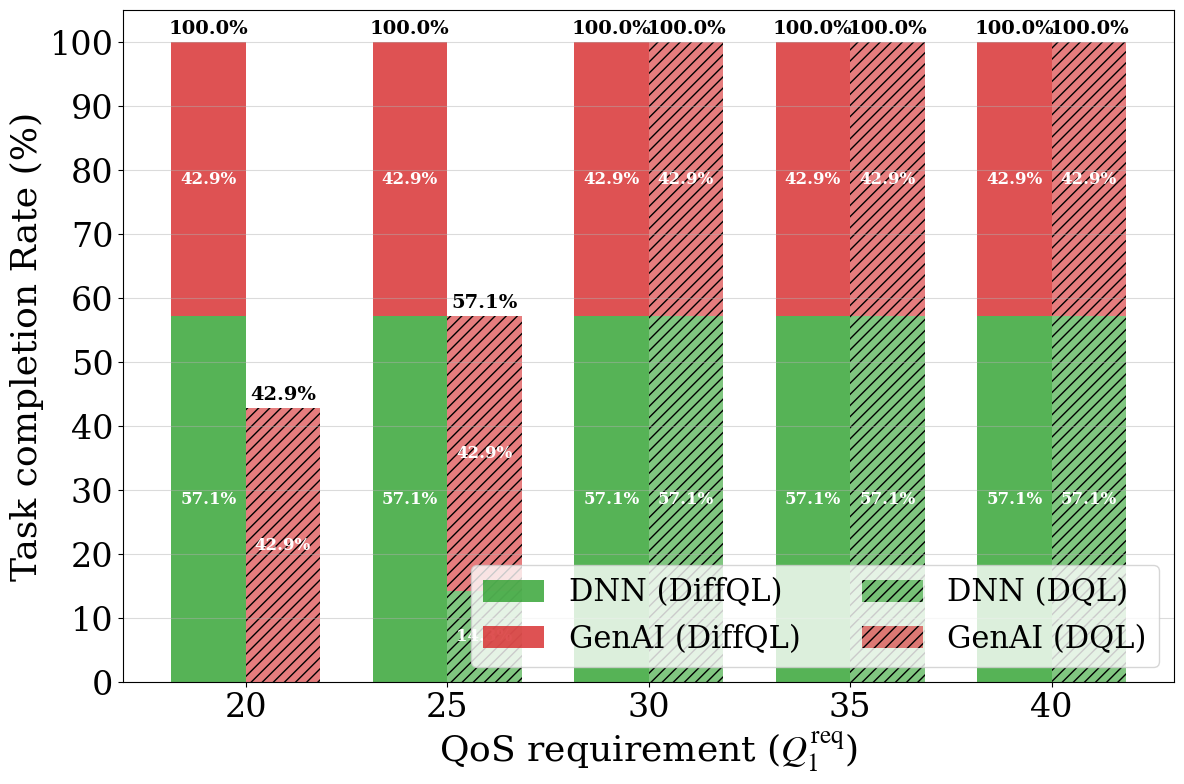


=== Task Completion Breakdown by Q_req ===
Total tasks: 7 (GenAI: 3, DNN: 4)
Q_req  Model    GenAI    DNN    Total%   GenAI%   DNN%    
------------------------------------------------------------
20     DiffQL   3        4      100.0    42.9     57.1    
20     DQL      3        0      42.9     42.9     0.0     

25     DiffQL   3        4      100.0    42.9     57.1    
25     DQL      3        1      57.1     42.9     14.3    

30     DiffQL   3        4      100.0    42.9     57.1    
30     DQL      3        4      100.0    42.9     57.1    

35     DiffQL   3        4      100.0    42.9     57.1    
35     DQL      3        4      100.0    42.9     57.1    

40     DiffQL   3        4      100.0    42.9     57.1    
40     DQL      3        4      100.0    42.9     57.1    



In [118]:
# Code 2: Stacked bar chart with GenAI/DNN composition
def plot_completion_composition_qreq():
    """
    Plot stacked bar chart showing GenAI vs DNN completion composition
    for different Q_req values with specific completion patterns
    """
    Q_req = ["20", "25", "30", "35", "40"]
    
    # Task configuration: 3 GenAI, 4 DNN tasks
    total_genai = 3
    total_dnn = 4
    total_tasks = total_genai + total_dnn
    
    # Completion data based on your specifications
    # DiffQL: 100% completion for all Q_req
    diffql_data = {
        'genai_completed': [3, 3, 3, 3, 3],  # All GenAI tasks completed
        'dnn_completed': [4, 4, 4, 4, 4],    # All DNN tasks completed
        'total_completion': [100, 100, 100, 100, 100]  # 100% overall
    }
    
    # DQL: Varying completion (3,0 and 3,1 for first two Q_req, then 100%)
    dql_data = {
        'genai_completed': [3, 3, 3, 3, 3],  # GenAI tasks completed
        'dnn_completed': [0, 1, 4, 4, 4],    # DNN tasks completed (0 for Q20, 1 for Q25, 4 for rest)
        'total_completion': [3/7*100, 4/7*100, 100, 100, 100]  # Overall completion rates
    }
    
    # Calculate completion rates as percentages
    diffql_genai_rate = [(g/total_genai) * (total_genai/total_tasks) * 100 for g in diffql_data['genai_completed']]
    diffql_dnn_rate = [(d/total_dnn) * (total_dnn/total_tasks) * 100 for d in diffql_data['dnn_completed']]
    
    dql_genai_rate = [(g/total_genai) * (total_genai/total_tasks) * 100 for g in dql_data['genai_completed']]
    dql_dnn_rate = [(d/total_dnn) * (total_dnn/total_tasks) * 100 for d in dql_data['dnn_completed']]
    
    # Plotting
    x_pos = np.arange(len(Q_req))
    bar_width = 0.37
    
    # Colors matching your existing code
    color_dnn = '#2ca02c'      # Green for DNN
    color_genai = '#d62728'    # Red for GenAI
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Grouped stacked bars: left = DiffQL, right = DQL
    left = x_pos - bar_width/2
    right = x_pos + bar_width/2
    
    # DiffQL stacked bars
    bars_diffql_dnn = ax.bar(left, diffql_dnn_rate, bar_width, 
                            color=color_dnn, alpha=0.8, label='DNN (DiffQL)')
    bars_diffql_genai = ax.bar(left, diffql_genai_rate, bar_width, 
                              bottom=diffql_dnn_rate, color=color_genai, alpha=0.8, 
                              label='GenAI (DiffQL)')
    
    # DQL stacked bars
    bars_dql_dnn = ax.bar(right, dql_dnn_rate, bar_width, 
                         color=color_dnn, alpha=0.6, hatch='///', label='DNN (DQL)')
    bars_dql_genai = ax.bar(right, dql_genai_rate, bar_width, 
                           bottom=dql_dnn_rate, color=color_genai, alpha=0.6, 
                           hatch='///', label='GenAI (DQL)')
    
    # Formatting
    ax.set_xlabel(r'QoS requirement ($Q_1^{\rm{req}}$)', fontsize=26)
    ax.set_ylabel('Task completion Rate (%)', fontsize=26)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(Q_req, fontsize=24)
    ax.set_ylim(0, 105)
    ax.set_yticks(np.arange(0, 110, 10))
    ax.set_yticklabels([f"{i}" for i in range(0, 110, 10)], fontsize=24)
    ax.grid(True, alpha=0.45, axis='y')
    ax.legend(ncol=2, loc='lower right', fontsize=22)
    
    # Add total completion labels above each stack
    for i in range(len(Q_req)):
        # DiffQL total
        total_diffql = diffql_dnn_rate[i] + diffql_genai_rate[i]
        if total_diffql > 0:
            ax.annotate(f'{total_diffql:.1f}%', 
                       xy=(left[i], total_diffql), xytext=(0, 3), 
                       textcoords='offset points', ha='center', va='bottom', 
                       fontsize=14, fontweight='bold')
        
        # DQL total
        total_dql = dql_dnn_rate[i] + dql_genai_rate[i]
        if total_dql > 0:
            ax.annotate(f'{total_dql:.1f}%', 
                       xy=(right[i], total_dql), xytext=(0, 3), 
                       textcoords='offset points', ha='center', va='bottom', 
                       fontsize=14, fontweight='bold')
    
    # Add internal labels for components > 5%
    for i in range(len(Q_req)):
        # DiffQL internal labels
        if diffql_dnn_rate[i] > 5:
            ax.annotate(f'{diffql_dnn_rate[i]:.1f}%', 
                       xy=(left[i], diffql_dnn_rate[i]/2), 
                       ha='center', va='center', fontsize=12, 
                       color='white', fontweight='bold')
        if diffql_genai_rate[i] > 5:
            ax.annotate(f'{diffql_genai_rate[i]:.1f}%', 
                       xy=(left[i], diffql_dnn_rate[i] + diffql_genai_rate[i]/2), 
                       ha='center', va='center', fontsize=12, 
                       color='white', fontweight='bold')
        
        # DQL internal labels
        if dql_dnn_rate[i] > 5:
            ax.annotate(f'{dql_dnn_rate[i]:.1f}%', 
                       xy=(right[i], dql_dnn_rate[i]/2), 
                       ha='center', va='center', fontsize=12, 
                       color='white', fontweight='bold')
        if dql_genai_rate[i] > 5:
            ax.annotate(f'{dql_genai_rate[i]:.1f}%', 
                       xy=(right[i], dql_dnn_rate[i] + dql_genai_rate[i]/2), 
                       ha='center', va='center', fontsize=12, 
                       color='white', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed breakdown table
    print("\n=== Task Completion Breakdown by Q_req ===")
    print(f"Total tasks: {total_tasks} (GenAI: {total_genai}, DNN: {total_dnn})")
    print(f"{'Q_req':<6} {'Model':<8} {'GenAI':<8} {'DNN':<6} {'Total%':<8} {'GenAI%':<8} {'DNN%':<8}")
    print("-" * 60)
    
    for i, q in enumerate(Q_req):
        # DiffQL row
        print(f"{q:<6} {'DiffQL':<8} {diffql_data['genai_completed'][i]:<8} "
              f"{diffql_data['dnn_completed'][i]:<6} {diffql_data['total_completion'][i]:<8.1f} "
              f"{diffql_genai_rate[i]:<8.1f} {diffql_dnn_rate[i]:<8.1f}")
        
        # DQL row
        print(f"{q:<6} {'DQL':<8} {dql_data['genai_completed'][i]:<8} "
              f"{dql_data['dnn_completed'][i]:<6} {dql_data['total_completion'][i]:<8.1f} "
              f"{dql_genai_rate[i]:<8.1f} {dql_dnn_rate[i]:<8.1f}")
        print()

# Run the stacked composition plot
plot_completion_composition_qreq()

## 4. Vẽ biểu đồ so sánh

Tạo 3 biểu đồ song song để so sánh toàn diện hiệu suất của hai thuật toán:

1. **Energy Consumption vs Q_req**: So sánh mức tiêu thụ năng lượng
2. **QoS Quality Score vs Q_req**: So sánh chất lượng dịch vụ  
3. **Task Completion Rate vs Q_req**: So sánh tỷ lệ hoàn thành nhiệm vụ

Các đường biểu diễn:
- **DiffQL** (màu xanh, đường liền với dấu tròn)
- **DQL** (màu cam, đường đứt với dấu vuông)

### Phân tích kết quả:
- **Completion Rate**: Cả hai thuật toán đều đạt tỷ lệ hoàn thành 100% (1.0)
- **Energy**: DiffQL ổn định hơn, DQL tăng mạnh từ Q_req=30
- **QoS**: Biến động nhiều ở cả hai thuật toán tùy theo Q_req